In [1]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

In [2]:
frames_path = "dataset/frames/"
frames = os.listdir(frames_path)
json_data_path = "dataset/json_data/model_plantvision_leaf.json"

In [3]:
from transformers import AutoModel
import torch.nn as nn
import torch.nn.functional as F
import pickle as pkl

with open(fr'leafLabelSet.pkl', 'rb') as f:
        leafLabelSet = pkl.load(f)

class PlantVision(nn.Module):
    def __init__(self, num_classes):
        super(PlantVision, self).__init__()
        self.vit = AutoModel.from_pretrained(r"google/vit-base-patch16-224-in21k")
        count = 0
        for child in self.vit.children():
            count += 1
            if count < 4:
                for param in child.parameters():
                    param.requires_grad = False
        self.vitLayers = list(self.vit.children()) 
        self.vitTop = nn.Sequential(*self.vitLayers[:-2])
        self.vitNorm = list(self.vit.children())[2]
        del self.vit
        self.vitFlatten = nn.Flatten()
        self.vitLinear = nn.Linear(151296, num_classes)
        self.fc = nn.Linear(num_classes, num_classes)

    def forward(self, input):
        output = self.vitTop(input).last_hidden_state
        output = self.vitNorm(output)
        output = self.vitFlatten(output)
        output = F.relu(self.vitLinear(output))
        output = self.fc(output)
        return output

In [4]:
model = PlantVision(num_classes=len(leafLabelSet))
model.load_state_dict(torch.load(fr"pretrained_models/plantvision-model-leaf.pt",  map_location='cpu', weights_only=True), strict=False)

<All keys matched successfully>

In [5]:
def preprocess_image(image):
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5],
                             std=[0.5, 0.5, 0.5])
    ])
    return preprocess(image)


def extract_features(model, input_tensor):
    model.eval()
    with torch.no_grad():
        features = model(input_tensor)
    return features


def load_img(img_path, target_size=None):
    """
    Load and optionally resize an image
    """

    img = Image.open(img_path)
    if target_size:
        img = img.resize(target_size)
    return np.array(img)


def visualize_embeddings(embeddings, prune_mask=None):
    """
    Visualizes image embeddings, mainting their position even after pruning.
    
    Parameters:
    - embeddings: 2D numpy array
    - prune_mask: Boolean mask of shape (N,) indicating which images to keep
    """

    plt.figure(figsize=(10, 8))

    # Default keep all images
    if prune_mask is None:
        prune_mask = np.ones(len(embeddings), dtype=bool)
    
    # Apply mask to embeddings
    pruned_embeddings = embeddings[prune_mask]
    pruned_frames = np.array(frames)[prune_mask] # Keep only unpruned frames

    for idx, point in enumerate(pruned_embeddings):
        x, y = point[0], point[1]
        plt.scatter(x, y, alpha=0) # Invis scatter points to hold positions

        img_path = os.path.join(frames_path, pruned_frames[idx])
        img = load_img(img_path, target_size=(50, 50))
        imagebox = OffsetImage(img, zoom=0.8)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, pad=0.1)
        plt.gca().add_artist(ab)

    plt.title("Image Embeddings")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.autoscale(True)
    plt.grid()
    plt.show()

In [ ]:
model_json_data = []
embeddings = []

for i, frame in enumerate(frames):
    img = Image.open(frames_path + frame)
    preprocessed_img = preprocess_image(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    features = extract_features(model, input_tensor)
    
    data = {
        "filename": f"frame{i}.jpg",
        "feature": features.cpu().numpy().flatten().tolist()
    }
    model_json_data.append(data)

    embeddings.append(features.flatten())

with open(json_data_path, 'w') as json_file:
    json.dump(model_json_data, json_file, indent=4)

embeddings = np.array(embeddings)

In [7]:
# Threshold for pruning similar embeddings
threshold = 25 # Percentage of average pairwise distance

# Compute pairwise Euclidean distance between all embeddings
pairwise_distance = np.linalg.norm(embeddings[:, np.newaxis] - embeddings, axis=2)

# Extract upper triangle of distance matrix (excluding diagonal)
upper_triangle = np.triu(pairwise_distance, k=1)

# Compute average distance between embeddings
average_distance = np.sum(upper_triangle) / np.count_nonzero(upper_triangle)

# Set pruning threshold based on average distance
prune_threshold = threshold * 0.01 * average_distance

# Identife pairs of embeddings that are too close
close_frames = np.where(pairwise_distance < prune_threshold)
redundant_imgs = []

# Remove redundant images (only keep first occurrence)
for i, j in zip(*close_frames):
    if i != j and i not in redundant_imgs:
        redundant_imgs.append(j)

# Prune embeddings by removing redundant ones
prune_mask = np.ones(len(embeddings), dtype=bool)
prune_mask[redundant_imgs] = False

84


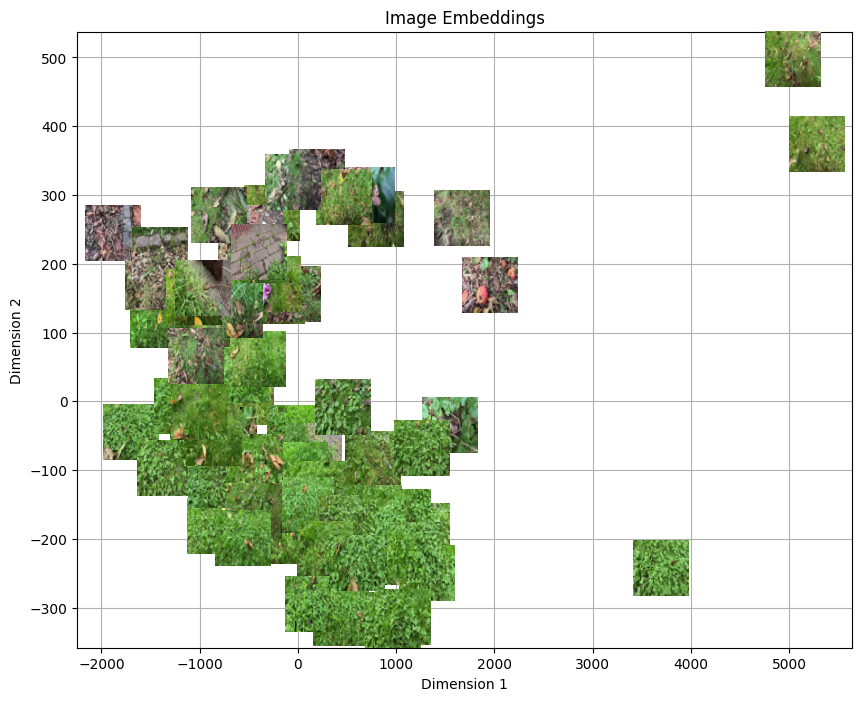

52


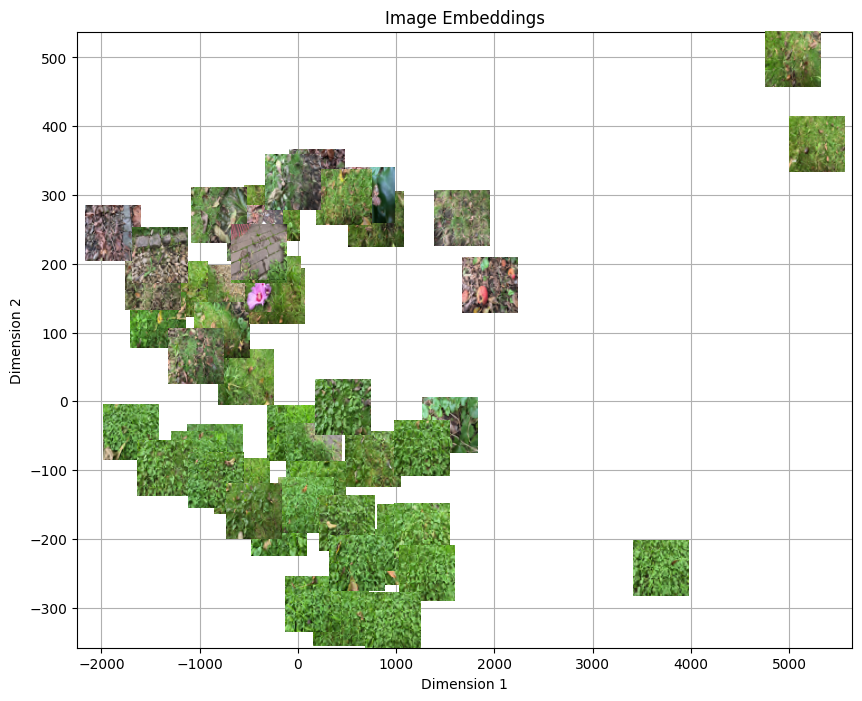

In [8]:
pca = PCA(n_components=2)
pca_results = pca.fit_transform(embeddings)

print(len(pca_results))
visualize_embeddings(pca_results)

print(len(pca_results[prune_mask]))
visualize_embeddings(pca_results, prune_mask)

c:\Users\Lars\Documents\%KUL\%Master\%Thesis\Python\BioBot\.venv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


84


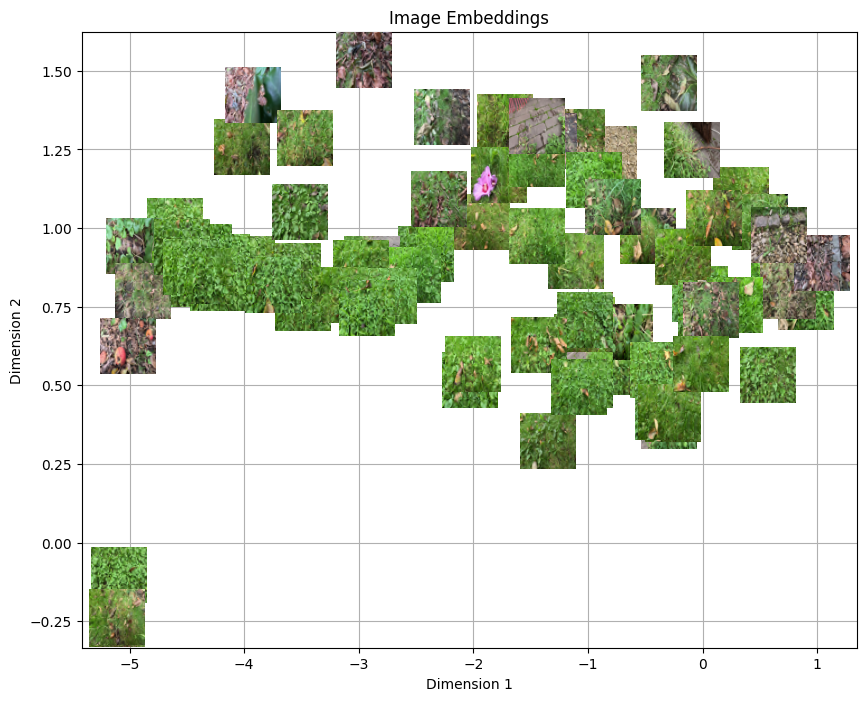

52


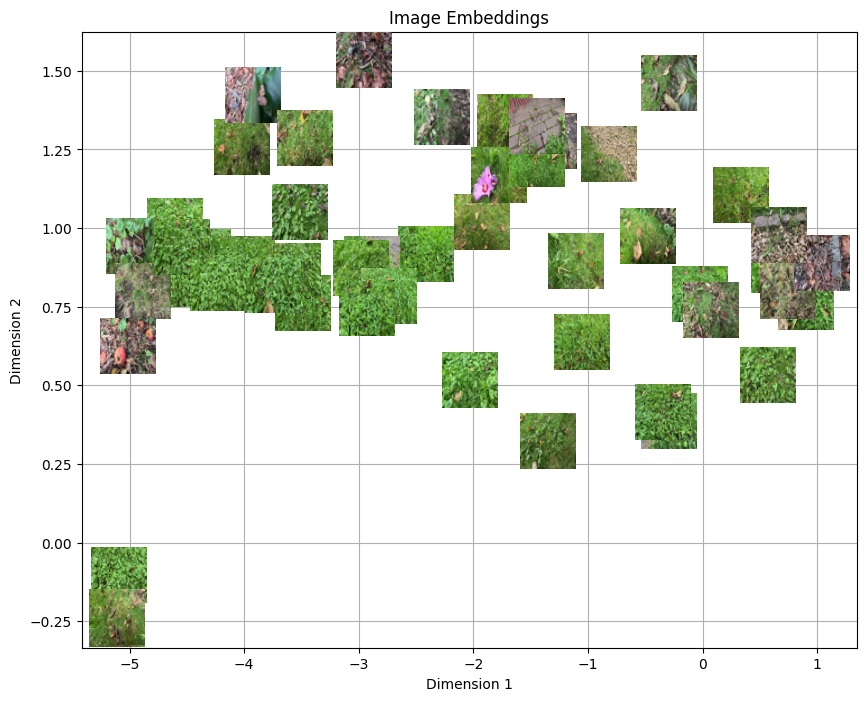

In [9]:
tsne = TSNE(n_components=2, perplexity=50)
tsne_results = tsne.fit_transform(embeddings)

print(len(tsne_results))
visualize_embeddings(tsne_results)

print(len(tsne_results[prune_mask]))
visualize_embeddings(tsne_results, prune_mask)

84


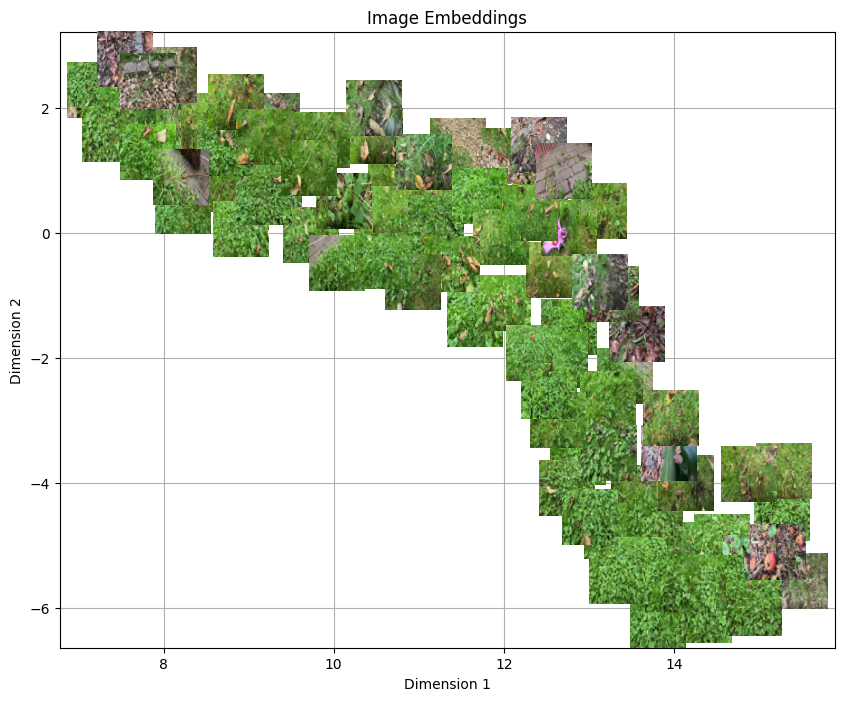

52


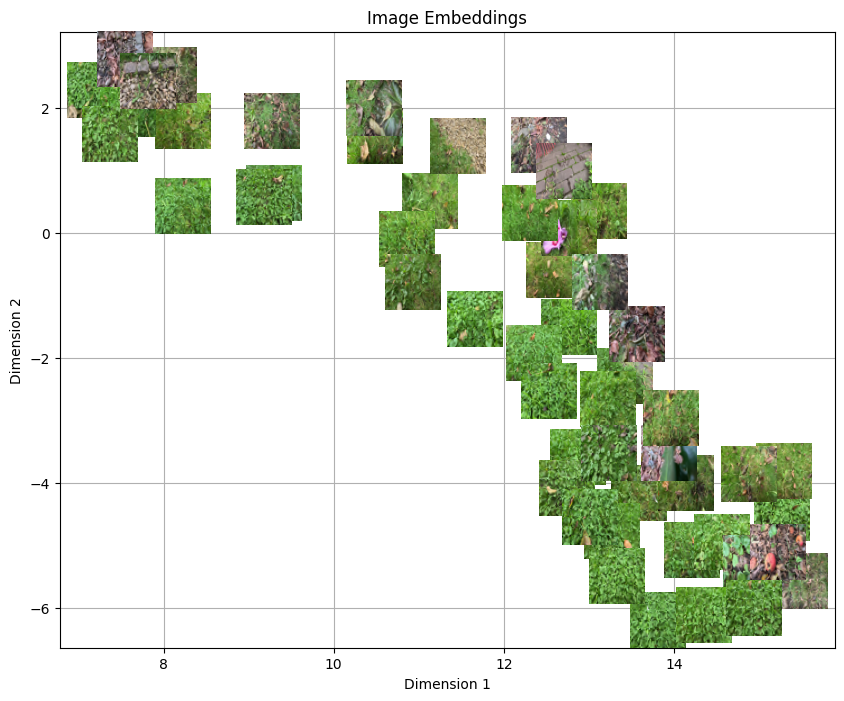

In [10]:
umap = UMAP(n_components=2, n_neighbors=50, min_dist=0.50)
umap_results = umap.fit_transform(embeddings)

print(len(umap_results))
visualize_embeddings(umap_results)

print(len(umap_results[prune_mask]))
visualize_embeddings(umap_results, prune_mask)